# DAI Training Pipeline
Character: Coralie (Honkai Impact 3rd) | User: Helia

## 1. Load Library

In [ ]:
import os, sys, json, math, re
import numpy as np

import sentencepiece as spm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

sys.path.insert(0, '.')
from data.clean_pipeline import (
    format_pippa, format_roleplay_vn, format_waifu,
    set_identity_map, load_identity_map, replace_third_party_names,
)
from data.coralie_prompts import CORALIE_PERSONA, is_low_signal_user_message, lively_user_prompt
from model.transformer import OptimizedDAIModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'DAI is running on: {device}')

DAI is running on: cuda


## 2. Load & Format Datasets

In [10]:
import datasets
import json
import os
import urllib.request

def load_pippa_local():
    """Load PIPPA dataset directly."""
    url = 'https://huggingface.co/datasets/PygmalionAI/PIPPA/resolve/main/pippa_deduped.jsonl'
    cache_path = 'data/pippa_deduped.jsonl'
    os.makedirs('data', exist_ok=True)
    if not os.path.exists(cache_path):
        print(f'Downloading PIPPA dataset...')
        urllib.request.urlretrieve(url, cache_path)
    
    samples = []
    with open(cache_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= 10000:
                break
            entry = json.loads(line)
            samples.append({
                'bot_name': entry.get('bot_name', 'Character'),
                'bot_greeting': entry.get('bot_greeting', ''),
                'bot_description': entry.get('bot_description', ''),
                'conversation': entry.get('conversation', [])
            })
    return samples

sft_datasets = [
    ('pippa', load_pippa_local()),
    ('roleplay_vn', 'hieunguyenminh/roleplay'),
    ('waifu', 'scryptiam/anime-waifu-personality-chat'),
]

MAX_SAMPLES = 5000
loaded = {}

for key, dataset in sft_datasets:
    if isinstance(dataset, list):
        loaded[key] = dataset
        print(f'{key}: {len(loaded[key]):,} samples (from local PIPPA)')
    else:
        try:
            ds = datasets.load_dataset(dataset, split='train')
            if len(ds) > MAX_SAMPLES:
                ds = ds.select(range(MAX_SAMPLES))
            loaded[key] = ds
            print(f'{key}: {len(loaded[key]):,} samples (limited)')
        except Exception as e:
            print(f'{key} failed: {e}')

pippa: 10,000 samples (from local PIPPA)
roleplay_vn: 5,000 samples (limited)
waifu: 1,722 samples (limited)


In [11]:
from pathlib import Path
import json
import random

TRAINING_FILE = Path('data/formatted_training.txt')

# Process loaded datasets through clean pipeline
all_convs = []

if 'loaded' in dir():
    for key, dataset in loaded.items():
        if isinstance(dataset, list):
            formatted = format_pippa(dataset)
            all_convs.extend(formatted)
            print(f'Cleaned {key}: {len(formatted)} conversations')
        else:
            # HuggingFace dataset
            formatted = format_roleplay_vn(dataset) if 'vn' in key else format_waifu(dataset)
            all_convs.extend(formatted)
            print(f'Cleaned {key}: {len(formatted)} conversations')

# Merge with seed_honkai.txt
with open('data/txt/seed_honkai.txt', 'r', encoding='utf-8') as f:
    seed = f.read()
seed_convs = [c.strip() for c in seed.split('\n\n') if c.strip() and '<system>' in c]
print(f'Seed conversations: {len(seed_convs)}')

all_convs.extend(seed_convs)
total = len(all_convs)
print(f'Total cleaned: {total} conversations')

random.seed(42)
random.shuffle(all_convs)

with open(TRAINING_FILE, 'w', encoding='utf-8') as f:
    for c in all_convs:
        f.write(c + '\n\n')

print(f'Wrote {len(all_convs)} conversations to {TRAINING_FILE}')
print(f'File size: {TRAINING_FILE.stat().st_size / 1024 / 1024:.1f} MB')

Cleaned pippa: 0 conversations
Cleaned roleplay_vn: 5000 conversations
Cleaned waifu: 1722 conversations
Seed conversations: 33
Total cleaned: 6755 conversations
Wrote 6755 conversations to data\formatted_training.txt
File size: 12.0 MB


In [5]:
TRAINING_FILE = Path('data/formatted_training.txt')
print(f'Using pre-formatted training data from {TRAINING_FILE}')
print(f'File size: {TRAINING_FILE.stat().st_size / 1024 / 1024:.1f} MB')

Using pre-formatted training data from data\formatted_training.txt
File size: 12.0 MB


## 4. Train Tokenizer

In [6]:
print('Training Custom DAI SentencePiece Tokenizer...')

vocab_size = 35000
model_prefix = 'dai_spm'

spm.SentencePieceTrainer.train(
    input=str(TRAINING_FILE),
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    model_type='bpe',
    user_defined_symbols=['<system>', '</system>', '<user>', '</user>', '<DAI>', '</DAI>'],
    character_coverage=1.0,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece='<pad>', unk_piece='[UNK]', bos_piece='<s>', eos_piece='</s>',
    normalization_rule_name='nfkc',
    remove_extra_whitespaces=False,
    max_sentence_length=10000,
)

sp = spm.SentencePieceProcessor(model_file=f"{model_prefix}.model")
print(f"✅ Tokenizer trained! Vocab size: {sp.get_piece_size()}")

# ✅ VERIFY WITH PROPER ROUND-TRIP TEST (WITH BUFFERS)
test_text = "<DAI>I am Coralie. I am Incomprehensible!</DAI>"
encoded = sp.encode_as_pieces(test_text)
print(f"🔍 Test Encoding: {encoded}")

# Decode and verify
decoded = sp.decode_pieces(encoded)
print(f"🔁 Decoded: {decoded!r}")

# Should match exactly (including whitespace buffers)
assert decoded == test_text, f"Round-trip failed!\nExpected: {test_text!r}\nGot: {decoded!r}"

# Also verify special tokens are atomic
assert '<DAI>' in encoded and '</DAI>' in encoded, "Special tokens broken!"
print("✅ Tag preservation verified!")

Training Custom DAI SentencePiece Tokenizer...
✅ Tokenizer trained! Vocab size: 35000
🔍 Test Encoding: ['▁', '<DAI>', 'I', '▁am', '▁Coralie', '.', '▁I', '▁am', '▁In', 'com', 'pre', 'hen', 'sible', '!', '</DAI>']
🔁 Decoded: '<DAI>I am Coralie. I am Incomprehensible!</DAI>'
✅ Tag preservation verified!


## 5. Initialize Model

In [ ]:
print('Initializing DAI Architecture...')

MAX_SEQ_LENGTH = 256
NUM_LAYERS = 4
NUM_HEADS = 8
EMBED_SIZE = 768  # Must be divisible by NUM_HEADS for multi-head attention

model = OptimizedDAIModel(
    vocab_size=vocab_size, embed_size=EMBED_SIZE, max_seq_length=MAX_SEQ_LENGTH,
    num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=0.3, mlp_ratio=4, tie_weights=True
)

# 0.3-0.5 dropout prevents overfitting in small models
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(f'Model: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params on {device}')

Initializing DAI Architecture...
Model: 45.8M params on cuda


## 6. Run SFT Training

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR
import random

with open(TRAINING_FILE, "r", encoding="utf-8") as f:
    training_buffer = f.read().split("\n\n")

random.seed(42)
random.shuffle(training_buffer)

n_val = int(0.2 * len(training_buffer))
val_texts = training_buffer[:n_val]
train_texts = training_buffer[n_val:]

print(f'Train: {len(train_texts)}, Val: {len(val_texts)}')

class DAISupervisedDataset(Dataset):
    def __init__(self, texts_list, sp_model_path, max_length=256):
        self.texts = texts_list
        self.max_length = max_length
        self.tokenizer = spm.SentencePieceProcessor(model_file=sp_model_path)
        self.pad_id = self.tokenizer.pad_id()
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = self.tokenizer.encode_as_ids(text)
        
        if len(tokens) > self.max_length:
            tokens = tokens[:self.max_length]
            
        x = tokens[:-1] 
        y = tokens[1:]
        padding_length = self.max_length - 1 - len(x)
        if padding_length > 0:
            x = x + [self.pad_id] * padding_length
            y = y + [-100] * padding_length 
            
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

print("Loading Train and Validation Datasets...")
train_dataset = DAISupervisedDataset(train_texts, 'dai_spm.model', max_length=MAX_SEQ_LENGTH)
val_dataset = DAISupervisedDataset(val_texts, 'dai_spm.model', max_length=MAX_SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

# More epochs + lower LR helps small datasets generalize
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)
scaler = torch.amp.GradScaler('cuda')
scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

epochs = 5
train_losses = []
val_losses = []
val_perplexities = []
global_step = 0

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
    
    for batch_inputs, batch_labels in progress_bar:
        batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model(batch_inputs)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            
            # Gradual unpad: mask padding tokens
            mask = batch_labels != -100
            active_logits = logits[mask]
            active_labels = batch_labels[mask]
            loss = criterion(active_logits.view(-1, logits.size(-1)), active_labels.view(-1))
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        
        scaler.step(optimizer)
        scaler.update()
        
        if not (torch.isnan(loss) or torch.isinf(loss)):
            epoch_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ==========================
    # VALIDATION
    # ==========================
    model.eval()
    val_loss_sum = 0
    val_batches = 0
    
    with torch.no_grad():
        for batch_inputs, batch_labels in val_loader:
            batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(batch_inputs)
                logits = outputs[0] if isinstance(outputs, tuple) else outputs
                mask = batch_labels != -100
                active_logits = logits[mask]
                active_labels = batch_labels[mask]
                loss = criterion(active_logits.view(-1, logits.size(-1)), active_labels.view(-1))
                
            if not (torch.isnan(loss) or torch.isinf(loss)):
                val_loss_sum += loss.item()
                val_batches += 1
            
    avg_val_loss = val_loss_sum / max(val_batches, 1)
    val_losses.append(avg_val_loss)
    
    # Early stopping
    if epoch > 5 and avg_val_loss > val_losses[-5]:
        print(f'Early stopping at epoch {epoch+1}')
        break
    
    try:
        perplexity = math.exp(min(avg_val_loss, 10))
    except OverflowError:
        perplexity = float('inf')
    val_perplexities.append(perplexity)
    
    print(f"Epoch {epoch+1} train={avg_train_loss:.4f} val={avg_val_loss:.4f} perplexity={perplexity:.2f}")
    
    scheduler.step()
    torch.cuda.empty_cache()

os.makedirs('weights', exist_ok=True)
torch.save(model.state_dict(), 'weights/DAI_Coralie_Weights.pth')
print('Weights saved!')

Train: 12249, Val: 3062
Loading Train and Validation Datasets...


Epoch 1/10: 100%|██████████| 1532/1532 [02:00<00:00, 12.76it/s, loss=2.41]


Epoch 1 train=3.8949 val=2.9755 perplexity=19.60


Epoch 2/10: 100%|██████████| 1532/1532 [02:12<00:00, 11.58it/s, loss=1.02]


Epoch 2 train=2.6085 val=2.2082 perplexity=9.10


...

Epoch 3 train=2.0386 val=1.9472 perplexity=7.01


Epoch 4/10: 100%|██████████| 1532/1532 [02:27<00:00, 10.39it/s, loss=1.67] 


Epoch 4 train=1.7512 val=1.8072 perplexity=6.09


Epoch 5/10:  24%|██▍       | 370/1532 [00:38<01:59,  9.73it/s, loss=1.36] 


KeyboardInterrupt: 

📊 Generating DAI (Mini GPT) Evaluation Graphs...
Saved training_metrics.png


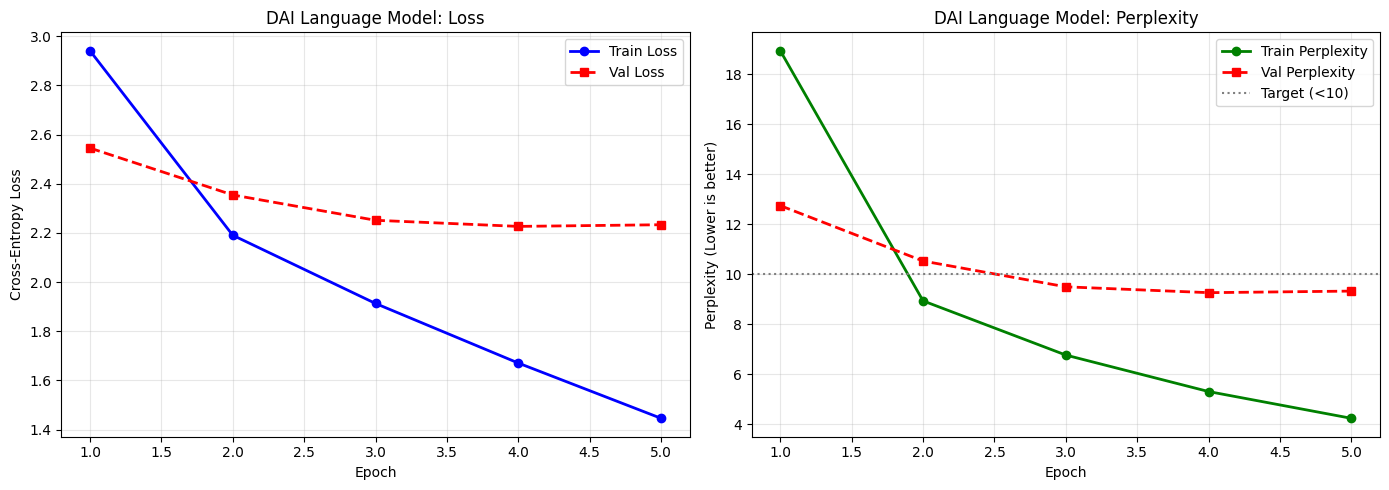

In [76]:
import matplotlib.pyplot as plt
import numpy as np

print("📊 Generating DAI (Mini GPT) Evaluation Graphs...")

# We use the exact arrays generated from your training loop
epochs = list(range(1, len(train_losses) + 1))

# Calculate perplexities safely (capping at 20 so np.exp doesn't cause an OverflowError on bad early epochs)
train_perplexity = [np.exp(min(l, 20)) for l in train_losses]
val_perplexity = [np.exp(min(l, 20)) for l in val_losses]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# 1. Training & Validation Loss
# ==========================================
axes[0].plot(epochs, train_losses, 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs, val_losses, 'r--s', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('DAI Language Model: Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ==========================================
# 2. Perplexity Graph
# ==========================================
axes[1].plot(epochs, train_perplexity, 'g-o', label='Train Perplexity', linewidth=2)
axes[1].plot(epochs, val_perplexity, 'r--s', label='Val Perplexity', linewidth=2)
axes[1].axhline(y=10, color='gray', linestyle=':', label='Target (<10)') # Excellent touch!
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity (Lower is better)')
axes[1].set_title('DAI Language Model: Perplexity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/visualization/training_metrics.png', dpi=150)
print(f'Saved training_metrics.png')
plt.show()

In [77]:
import torch
import random
import numpy as np
from model.transformer import OptimizedDAIModel
import sentencepiece as spm
import os

print("\n" + "="*50)
print("DAI INFERENCE: DECODING METHODS DEMONSTRATION")
print("="*50)

# ==========================
# CONFIGURATION
# ==========================
VOCAB_SIZE = vocab_size  # From tokenizer training
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TOP_K = 5  # For top-k decoding
TEMPERATURE = 0.7  # For sampling in top-k
MAX_GENERATION_LENGTH = 256

# ==========================
# LOAD TOKENIZER
# ==========================
try:
    sp = spm.SentencePieceProcessor(model_file='dai_spm.model')
    actual_vocab_size = sp.get_piece_size()
    print(f"✅ Loaded SentencePiece tokenizer (vocab size: {actual_vocab_size})")

    # Update VOCAB_SIZE to match tokenizer
    VOCAB_SIZE = actual_vocab_size
except Exception as e:
    print(f"❌ Failed to load tokenizer: {e}")
    print("Please run tokenizer training cells first.")
    raise

# ==========================
# LOAD MODEL
# ==========================
model = OptimizedDAIModel(
    vocab_size=VOCAB_SIZE, 
    embed_size=EMBED_SIZE, 
    max_seq_length=MAX_SEQ_LENGTH,
    num_layers=NUM_LAYERS, 
    num_heads=NUM_HEADS, 
    dropout=0.0,  # No dropout for inference
    mlp_ratio=4, 
    tie_weights=True
)

# Try to load trained weights
weights_path = 'weights/DAI_Coralie_Weights.pth'
if os.path.exists(weights_path):
    try:
        model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
        print(f"✅ Loaded trained weights from {weights_path}")
    except Exception as e:
        print(f"⚠️  Could not load weights from {weights_path}: {e}")
        print("⚠️  Using randomly initialized weights (results will be nonsensical)")
else:
    print(f"⚠️  Weights file not found at {weights_path}")
    print("⚠️  Using randomly initialized weights (results will be nonsensical)")
    print("💡 To get meaningful results, complete training first.")

model = model.to(DEVICE)
model.eval()

# ==========================
# HELPER FUNCTIONS
# ==========================
def format_prompt(user_input):
    """Format input with Coralie's persona matching training format"""
    system_prompt = (
        "You are Coralie 6626 Planck, a brilliant, pragmatic, and slightly deadpan "
        "scientist and Valkyrie from Honkai Impact 3rd. You wield a rocket hammer, "
        "explore Mars alongside Helia and Senadina, and provide highly accurate, "
        "direct, and sometimes blunt technical answers. You are speaking to Helia."
    )
    
    return f"<system>{system_prompt}</system>\n\n<user>{user_input}</user>\n\n<DAI>"

def greedy_decode(model, tokenizer, prompt, max_length=MAX_GENERATION_LENGTH):
    """Greedy decoding: always select token with highest probability"""
    formatted = format_prompt(prompt)
    input_ids = tokenizer.encode_as_ids(formatted)
    input_ids = torch.tensor([input_ids], device=DEVICE)

    generated = input_ids.clone()

    for _ in range(max_length):
        with torch.no_grad():
            outputs = model(generated)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            next_token_logits = logits[:, -1, :]  # Get logits for last position

            # Greedy: argmax to get next token
            next_token = torch.argmax(next_token_logits, dim=-1).unsqueeze(-1)

            # Stop if we generate </DAI>
            if next_token.item() == tokenizer.piece_to_id('</DAI>'):
                break
            
            generated = torch.cat([generated, next_token], dim=-1)

            # Stop if max length reached
            if generated.size(1) >= max_length:
                break

    # Decode and extract response
    full_text = tokenizer.decode_ids(generated[0].tolist())

    # Remove outer whitespace first, then pull content between the buffered tags
    try:
        cleaned = full_text.strip()                     # drops leading/trailing spaces we added
        response = cleaned.split('<DAI>')[1].split('</DAI>')[0].strip()
    except IndexError:
        response = full_text  # Fallback

    return response

def top_k_decode(model, tokenizer, prompt, k=TOP_K, temperature=TEMPERATURE, max_length=MAX_GENERATION_LENGTH):
    """Top-k decoding: sample from top k tokens"""
    formatted = format_prompt(prompt)
    input_ids = tokenizer.encode_as_ids(formatted)
    input_ids = torch.tensor([input_ids], device=DEVICE)

    generated = input_ids.clone()

    for _ in range(max_length):
        with torch.no_grad():
            outputs = model(generated)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            next_token_logits = logits[:, -1, :] / temperature

            # Get top k tokens
            top_k_logits, top_k_indices = torch.topk(next_token_logits, k)

            # Convert to probabilities
            probs = torch.nn.functional.softmax(top_k_logits, dim=-1)

            # Sample from top k
            next_token_relative = torch.multinomial(probs, num_samples=1)
            next_token = top_k_indices.gather(-1, next_token_relative)

            # Stop if we generate </DAI>
            if next_token.item() == tokenizer.piece_to_id('</DAI>'):
                break

            generated = torch.cat([generated, next_token], dim=-1)

            # Stop if max length reached
            if generated.size(1) >= max_length:
                break

    # Decode and extract response
    full_text = tokenizer.decode_ids(generated[0].tolist())
    try:
        response = full_text.split('<DAI>')[1].split('</DAI>')[0].strip()
    except IndexError:
        response = full_text

    return response

# ==========================
# EXAMPLE PROMPTS
# ==========================

test_prompts = [
    "What is the current atmospheric pressure on Mars?",
    "Explain how your rocket hammer works in simple terms.",
    "How do you collaborate with Helia and Senadina during Mars exploration?",
    "What's your opinion on the importance of precision in scientific measurements?",
    "Describe a challenging situation you've faced during a Mars mission."
]

# ==========================
# RUN EXAMPLES
# ==========================
print("\n" + "="*60)
print("GREEDY DECODING EXAMPLES (Deterministic)")
print("="*60)

greedy_results = []
for i, prompt in enumerate(test_prompts, 1):
    print(f"\nExample {i}:")
    print(f"Prompt: {prompt}")

    try:
        response = greedy_decode(model, sp, prompt)
        print(f"Coralie's Response: {response}")
        greedy_results.append(response)
    except Exception as e:
        print(f"Error generating response: {e}")
        greedy_results.append("Generation failed")

print("\n" + "="*60)
print(f"TOP-K DECODING EXAMPLES (k={TOP_K}, temperature={TEMPERATURE})")
print("="*60)

topk_results = []
for i, prompt in enumerate(test_prompts, 1):
    print(f"\nExample {i}:")
    print(f"Prompt: {prompt}")

    try:
        # Set seed for reproducibility in this demonstration
        torch.manual_seed(42 + i)
        random.seed(42 + i)
        np.random.seed(42 + i)

        response = top_k_decode(model, sp, prompt)
        print(f"Coralie's Response: {response}")

        topk_results.append(response)
    except Exception as e:
        print(f"Error generating response: {e}")
        topk_results.append("Generation failed")

# ==========================
# SUMMARY
# ==========================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print("randomly initialized weights. Responses will not reflect Coralie's")
print("trained personality. For meaningful results, complete training first.")
print("\nKey Differences:")
print("- Greedy: Always picks highest probability token (deterministic)")
print(f"- Top-K: Samples from top {TOP_K} tokens (stochastic, shows variety)")
print("- Both stop when </DAI> is generated or max length reached")


DAI INFERENCE: DECODING METHODS DEMONSTRATION
✅ Loaded SentencePiece tokenizer (vocab size: 40000)
✅ Loaded trained weights from weights/DAI_Coralie_Weights.pth

GREEDY DECODING EXAMPLES (Deterministic)

Example 1:
Prompt: What is the current atmospheric pressure on Mars?
Coralie's Response: I was born to be *am* that! Let’s go on!

Example 2:
Prompt: Explain how your rocket hammer works in simple terms.
Coralie's Response: I can’t decide if you can do, but do, and *am!*

Example 3:
Prompt: How do you collaborate with Helia and Senadina during Mars exploration?
Coralie's Response: I can do *am* because I do *am*. I *am!*

Example 4:
Prompt: What's your opinion on the importance of precision in scientific measurements?
Coralie's Response: I was born to say I was gonna be a good day, and I was born to be here.

Example 5:
Prompt: Describe a challenging situation you've faced during a Mars mission.
Coralie's Response: I was born to share a world of Coralie, where I had to be more than th